# Heston GPU Monte Carlo — Colab quick run

**Runtime → Change runtime type → GPU** (T4 / L4 / …).

If this notebook lives in a **subfolder** of a monorepo, set `PROJECT_SUBDIR` (see cell 2).

In [11]:
!nvidia-smi

Sun Mar 29 21:00:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
import os, shutil, subprocess
from pathlib import Path

# --- edit for your GitHub repository ---
REPO_URL = "https://github.com/chezke/Monte-Carlo-simulation-of-Heston-model.git"
BRANCH = "main"
# If repo root is *not* this project, cd into it after clone (use "" if notebook lives at repo root):
PROJECT_SUBDIR = ""  # example: "Monte Carlo simulation of Heston model" or "heston-mc"

CLONE_DIR = "/content/heston_mc_src"
SAFE_DIR = "/content"

def safe_chdir(path: str):
    Path(path).mkdir(parents=True, exist_ok=True)
    os.chdir(path)
    print("cwd:", os.getcwd())
safe_chdir(SAFE_DIR)

if os.path.isdir(CLONE_DIR):
    shutil.rmtree(CLONE_DIR)
subprocess.run(
    ["git", "clone", "-q", "--depth", "1", "-b", BRANCH, REPO_URL, CLONE_DIR],
    check=True,
)
os.chdir(CLONE_DIR)
if PROJECT_SUBDIR:
    os.chdir(PROJECT_SUBDIR)
print("cwd:", os.getcwd())
!ls -la

cwd: /content
cwd: /content/heston_mc_src
total 52
drwxr-xr-x 6 root root  4096 Mar 29 21:00 .
drwxr-xr-x 1 root root  4096 Mar 29 21:00 ..
-rw-r--r-- 1 root root 12292 Mar 29 21:00 .DS_Store
drwxr-xr-x 8 root root  4096 Mar 29 21:00 .git
-rw-r--r-- 1 root root    38 Mar 29 21:00 .gitignore
drwxr-xr-x 2 root root  4096 Mar 29 21:00 include
-rw-r--r-- 1 root root   469 Mar 29 21:00 Makefile
drwxr-xr-x 2 root root  4096 Mar 29 21:00 notebooks
-rw-r--r-- 1 root root  3145 Mar 29 21:00 README.md
drwxr-xr-x 2 root root  4096 Mar 29 21:00 src


In [13]:
# Colab GPU images usually ship nvcc; if 'make' fails, try: which nvcc
!make clean 2>/dev/null; make NVFLAGS="-O3 -std=c++14 -Iinclude"

rm -rf bin
nvcc -O3 -std=c++14 -Iinclude  src/MC_almost.cu -o bin/MC_almost
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc -O3 -std=c++14 -Iinclude  src/MC_benchmark_Q3.cu -o bin/MC_benchmark_Q3
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc -O3 -std=c++14 -Iinclude  src/MC_Euler.cu -o bin/MC_Euler
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc -O3 -std=c++14 -Iinclude  src/MC_exact.cu -o bin/MC_exact
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-tar

In [14]:
!./bin/MC_Euler

Heston Euler MC (Proj2026 Q1)
Parameters: kappa=0.5, theta=0.1, sigma=0.3, rho=-0.7, dt=0.001, n_steps=1000
Paths: 262144 (CUDA threads launched: 262144)
Variance truncation g: positive part (.)+ 
Estimated E[(S_T - K)+]  = 0.11960698
95% CI half-width        = 0.00067531
Execution time (kernel)   = 9.724 ms


In [15]:
!./bin/MC_exact

Heston exact scheme MC (Proj2026, Steps 1–3 + [8] Gamma)
Parameters: kappa=0.5, theta=0.1, sigma=0.3, rho=-0.7, dt=0.001, n_steps=1000, T=1
Paths: 262144 (CUDA threads launched: 262144)
Estimated call (undiscounted) = 0.11755245
95% CI half-width             = 0.00067086
Execution time (kernel)      = 716.480 ms


In [16]:
# Q3 sweep can be slow; reduce grid/path count via NVFLAGS if needed
# !make NVFLAGS="-O3 -std=c++14 -Iinclude -DHESTON_Q3_N_PATHS=16384" bin/MC_benchmark_Q3
!./bin/MC_benchmark_Q3 > results_q3.csv

# Done. Rows printed: 480
# Reference: mean_exact (Broadie–Kaya-style exact). err_* is bias+MC noise vs that run; increase N_PATHS to shrink MC noise.
# dt=1/30 almost-exact: fewer steps -> often faster; |err_almost_30| may exceed |err_almost_1000| (logS discretization).


## Q3 Analysis — Euler vs Almost-exact

We focus on three points:
1. Runtime
2. Error vs Broadie–Kaya reference (`err_* = mean_* - mean_exact`)
3. Effect of coarse step size (`Δt = 1/30`) in the almost-exact scheme

In [18]:
import pandas as pd

df = pd.read_csv("results_q3.csv", comment="#")
print(f"Loaded {len(df)} parameter combinations (Feller-filtered)")
df.head()

Loaded 480 parameter combinations (Feller-filtered)


,id,kappa,theta,sigma,feller_gap,ms_exact,ms_euler,ms_almost_dt1000,ms_almost_dt1_30,mean_exact,mean_euler,mean_almost_1000,mean_almost_30,err_euler,err_almost_1000,err_almost_30
0,0,0.1,0.01,0.100000,0.010000,136.316,3.99373,141.177,17.6210,0.121797,0.121142,0.121778,0.123215,-0.000655,-0.000019,0.001418
1,1,0.1,0.08,0.100000,0.150000,136.215,3.92957,140.732,17.7315,0.122998,0.123539,0.122821,0.124490,0.000541,-0.000177,0.001492
2,2,0.1,0.08,0.228571,0.107755,675.521,3.59411,670.349,15.4040,0.115772,0.120581,0.113922,0.120779,0.004809,-0.001850,0.005007
3,3,0.1,0.08,0.357143,0.032449,615.375,3.67539,618.615,11.1152,0.115489,0.116004,0.112247,0.115463,0.000516,-0.003242,-0.000026
4,4,0.1,0.15,0.100000,0.290000,136.923,3.99315,140.659,17.7630,0.126514,0.125749,0.124989,0.126112,-0.000765,-0.001525,-0.000402


### 1. Runtime comparison

Euler uses simple per-step arithmetic.
BK-exact and almost-exact require Poisson + Gamma sampling each step, so at the same `Δt` they should be much slower.

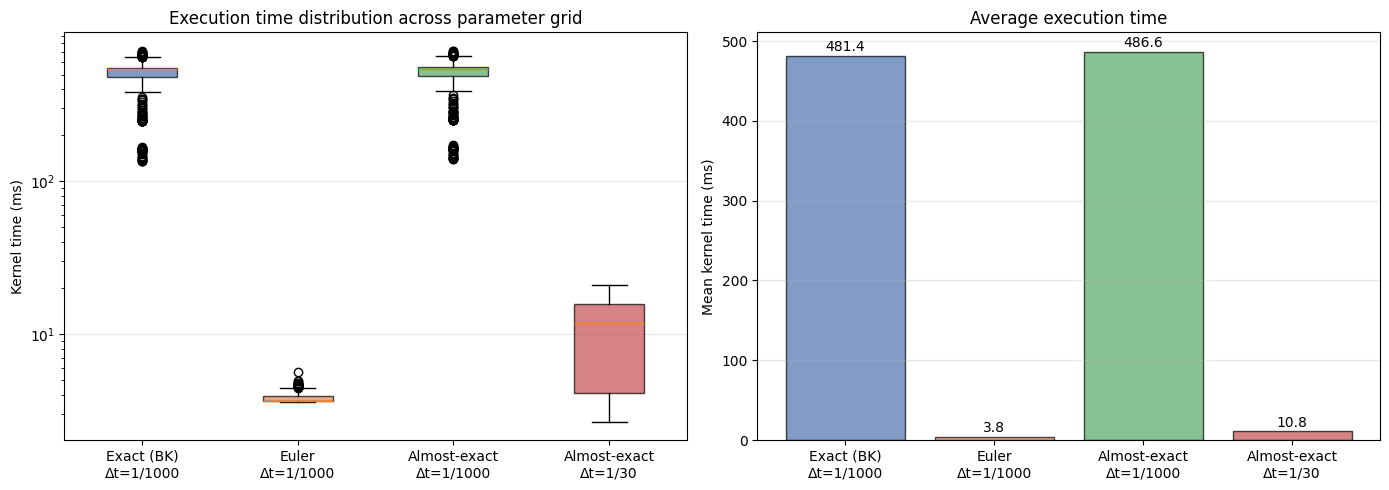

Mean execution time (ms):
  Exact (BK)
Δt=1/1000              481.36 ± 152.85
  Euler
Δt=1/1000                     3.85 ±   0.34
  Almost-exact
Δt=1/1000            486.64 ± 153.07
  Almost-exact
Δt=1/30               10.84 ±   5.95

Speedup  Euler / Exact (BK):            125.1×
Speedup  Almost Δt=1/30 / Almost Δt=1/1000: 44.9×


In [20]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "notebooks"))
from q3_plots import plot_execution_time, plot_error_analysis, plot_dt_impact

plot_execution_time(df)

### 2. Error comparison

`err_* = mean_* - mean_exact`, with BK (`Δt = 1/1000`) as the MC reference.
So each `err_*` contains both discretization error and residual MC noise.

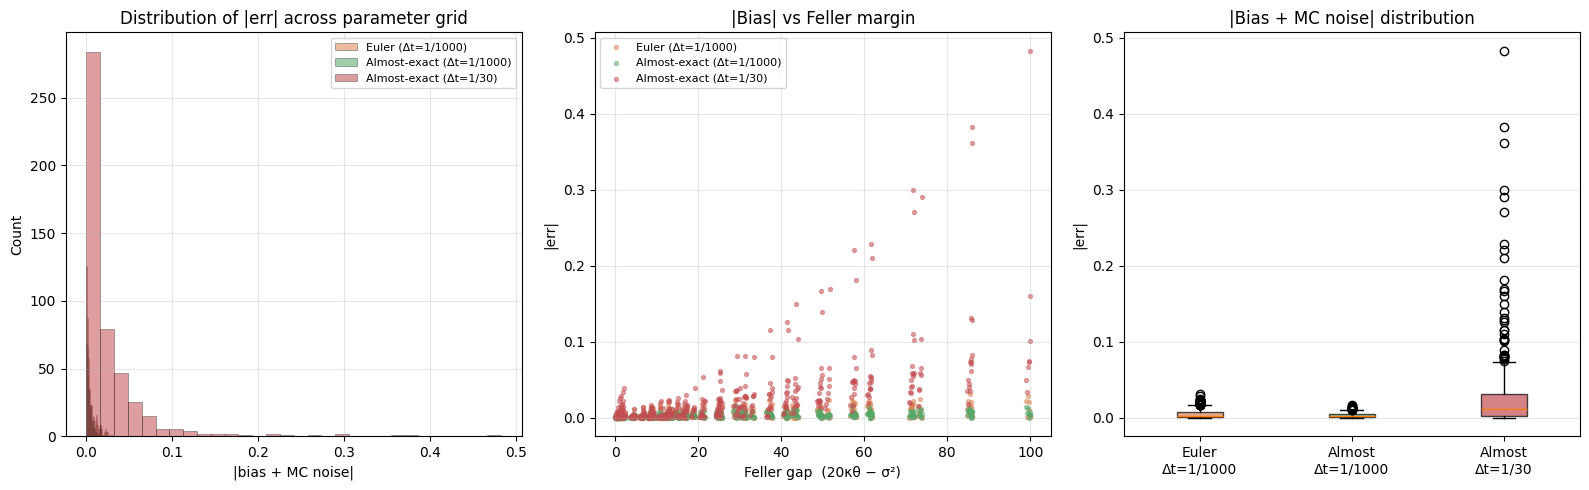

Absolute error statistics:
  Method                        mean |err|      median         max
  Euler (Δt=1/1000)               0.004955    0.002457    0.030890
  Almost-exact (Δt=1/1000)        0.003288    0.002294    0.016815
  Almost-exact (Δt=1/30)          0.026775    0.011316    0.482913


In [21]:
plot_error_analysis(df)

### 3. Effect of `Δt = 1/30` in almost-exact

Using fewer steps gives a large runtime gain.
The tradeoff is larger log-price discretization error, so `|err|` usually increases.

Below we compare `Δt = 1/1000` and `Δt = 1/30` directly.

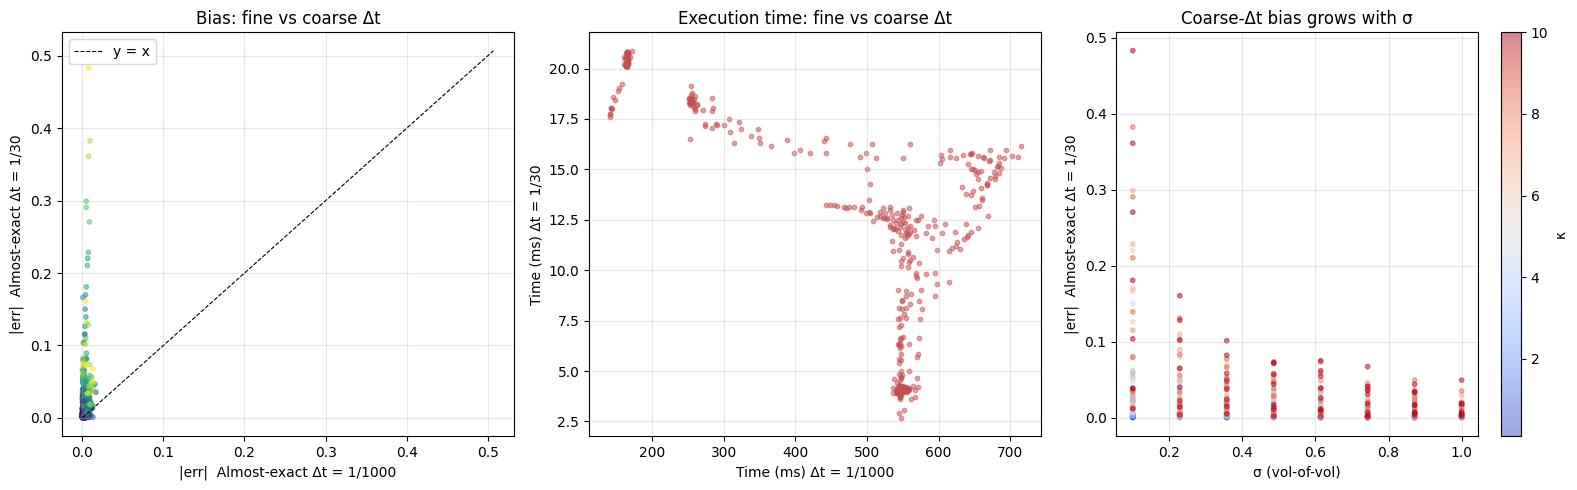

Fraction of cases where |err(Δt=1/30)| > |err(Δt=1/1000)|: 82.5%
Mean |err|  Δt=1/1000: 0.003288
Mean |err|  Δt=1/30  : 0.026775
Ratio: 8.14×

Mean time  Δt=1/1000: 486.6 ms
Mean time  Δt=1/30  : 10.8 ms
Speedup: 44.9×


In [22]:
plot_dt_impact(df)

### 4. Key takeaways

- **Speed:** Euler (`Δt=1/1000`) is the fastest method (3.9 ms) and more accurate than almost-exact with `Δt=1/30`.
- **Costly methods:** BK-exact and almost-exact at the same `Δt=1/1000` have similar runtime (~485 ms), both ~125× slower than Euler.
- **Best accuracy:** Almost-exact (`Δt=1/1000`) achieves the lowest mean |err| (0.003), beating Euler (0.005), but at 125× the cost.
- **Coarse `Δt=1/30`:** Gives a 44.9× speed-up over fine almost-exact, but the error (0.027) is worse than Euler. Its value lies in keeping variance exact regardless of `Δt` — a property Euler cannot offer.
- **Practical guideline:** For raw speed, Euler with fine `Δt` is hard to beat. The almost-exact scheme is most valuable when exact variance dynamics matter (e.g., pricing variance-sensitive products) or when comparing methods at the same coarse `Δt`, where Euler's error would be far larger.